In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
 
# Preprocessing
BINARY_COLS = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

FURNISHING_ORDER = {"unfurnished":  0, "semi-furnished": 1, "furnished":  2}


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in BINARY_COLS:
        df[col] = (df[col].str.strip().str.lower() == "yes").astype(int)
    df["furnishingstatus"] = (df["furnishingstatus"].str.strip().str.lower().map(FURNISHING_ORDER))
    return df


#loading and splitting, only using area 
 
df_clean = preprocess(pd.read_csv("project_dataset_housing.csv"))
 
X = df_clean["area"].values          
y = df_clean["price"].values
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
#nadaraya watson estimator 

def gaussian_kernel(u):
    return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
 
def nw_predict(x_train, y_train, x_new, h):
    preds = []
    for x in x_new:
        w = gaussian_kernel((x_train - x) / h)
        preds.append(np.sum(w * y_train) / (np.sum(w) + 1e-8))
    return np.array(preds)
 
# tuning h, 5 fold validation
 
bandwidths = np.logspace(2, 4.5, 50)    
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_errors  = []
 
for h in bandwidths:
    fold_mses = []
    for train_idx, val_idx in kf.split(X_train):
        x_tr, x_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        y_pred_val  = nw_predict(x_tr, y_tr, x_val, h)
        fold_mses.append(np.mean((y_val - y_pred_val) ** 2))
    cv_errors.append(np.mean(fold_mses))
 
best_h = bandwidths[np.argmin(cv_errors)]
best_cv_mse = min(cv_errors)
 
print(f"Best h (bandwidth) :{best_h:.2f}")
print(f"Best CV MSE : {best_cv_mse:,.0f}")

# evaluation on testing set

y_pred   = nw_predict(X_train, y_train, X_test, best_h)
test_mse = np.mean((y_test - y_pred) ** 2)
 
print(f"\n Test Set Performance ")
print(f"MSE  : {test_mse:>20,.2f}")
print(f"RMSE : {np.sqrt(test_mse):>20,.2f}")

Best h (bandwidth) :364.10
Best CV MSE : 2,066,902,926,422

 Test Set Performance 
MSE  : 3,795,369,394,483.85
RMSE :         1,948,170.78


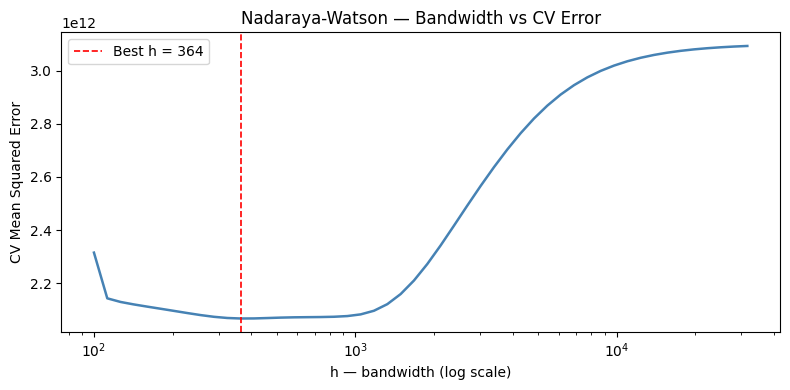

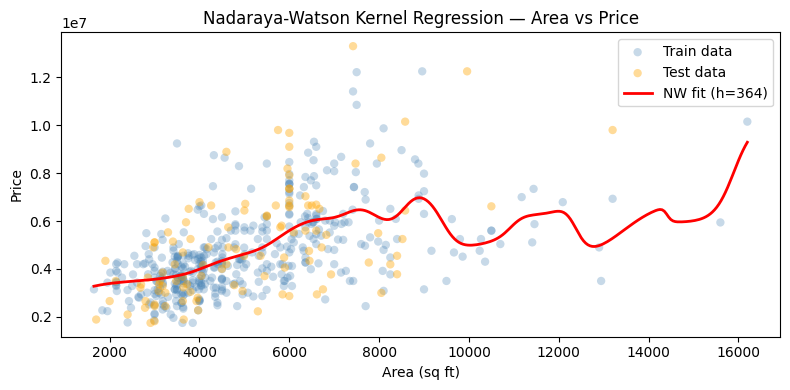

In [9]:
# plotting h vs CV error
 
plt.figure(figsize=(8, 4))
plt.semilogx(bandwidths, cv_errors, color="steelblue", linewidth=1.8)
plt.axvline(best_h, color="red", linestyle="--", linewidth=1.2,
            label=f"Best h = {best_h:.0f}")
plt.xlabel("h — bandwidth (log scale)")
plt.ylabel("CV Mean Squared Error")
plt.title("Nadaraya-Watson — Bandwidth vs CV Error")
plt.legend()
plt.tight_layout()
plt.show()
 
# plotting fitted curve + scatterplot
 
x_range  = np.linspace(X.min(), X.max(), 300)
y_fitted = nw_predict(X_train, y_train, x_range, best_h)
 
plt.figure(figsize=(8, 4))
plt.scatter(X_train, y_train, alpha=0.3, color="steelblue",
            edgecolors="none", label="Train data")
plt.scatter(X_test, y_test, alpha=0.4, color="orange",
            edgecolors="none", label="Test data")
plt.plot(x_range, y_fitted, color="red", linewidth=2, label=f"NW fit (h={best_h:.0f})")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Nadaraya-Watson Kernel Regression — Area vs Price")
plt.legend()
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=cca14342-032d-4c69-8309-45231d7b44b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>